# Two feature study

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


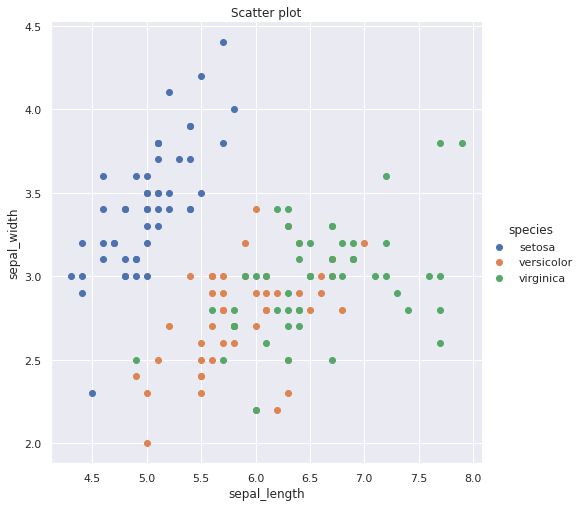

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import itertools
from scipy.stats import norm
import scipy.stats
%matplotlib inline
sns.set()

#Load the data set
iris = sns.load_dataset("iris")
iris.info()

#Plot the scatter of sepal length vs sepal width
sns.FacetGrid(iris, hue="species", height=7) .map(plt.scatter,"sepal_length", "sepal_width", )  .add_legend()
plt.title('Scatter plot')
df1 = iris[["sepal_length", "sepal_width",'species']]

In [ ]:
def predict_NB_gaussian_class(X,mu_list,std_list,pi_list): 
    #Returns the class for which the Gaussian Naive Bayes objective function has greatest value
    scores_list = []
    classes = len(mu_list)
    
    for p in range(classes):
        score = (norm.pdf(x = X[0], loc = mu_list[p][0][0], scale = std_list[p][0][0] )  
                * norm.pdf(x = X[1], loc = mu_list[p][0][1], scale = std_list[p][0][1] ) 
                * pi_list[p])
        scores_list.append(score)
    
    # print(scores_list)
             
    return np.argmax(scores_list)

In [ ]:
#Estimating the parameters
mu_list = np.split(df1.groupby('species').mean().values,[1,2])
std_list = np.split(df1.groupby('species').std().values,[1,2], axis = 0)
pi_list = df1.iloc[:,2].value_counts().values / len(df1)

# Our 2-dimensional distribution will be over variables X and Y
N = 100
X = np.linspace(4, 8, N)
Y = np.linspace(1.5, 5, N)
X, Y = np.meshgrid(X, Y)

mu_list

[array([[5.006, 3.428]]), array([[5.936, 2.77 ]]), array([[6.588, 2.974]])]

In [ ]:
std_list

[array([[0.35248969, 0.37906437]]),
 array([[0.51617115, 0.31379832]]),
 array([[0.63587959, 0.32249664]])]

In [ ]:
pi_list

array([0.33333333, 0.33333333, 0.33333333])

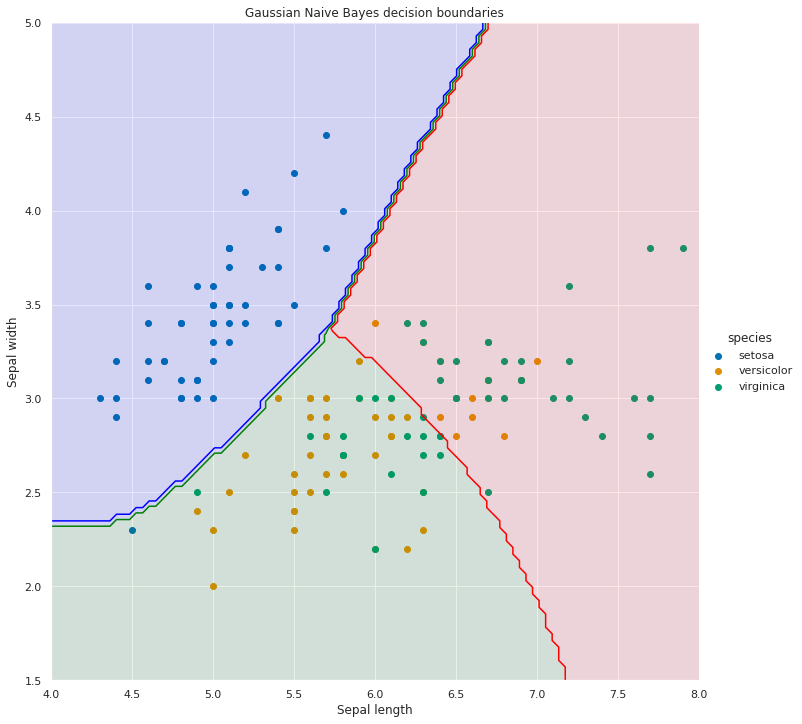

In [ ]:
#Computing the predicted class function for each value on the grid
zz = np.array([predict_NB_gaussian_class( np.array([xx,yy]).reshape(-1,1), mu_list, std_list, pi_list) 
                     for xx, yy in zip(np.ravel(X), np.ravel(Y)) ])

#Reshaping the predicted class into the meshgrid shape
Z = zz.reshape(X.shape)

color_list = ['Blues','Greens','Reds']
my_norm = colors.Normalize(vmin=-1.,vmax=1.)
g = sns.FacetGrid(iris, hue="species", height=10, palette = 'colorblind').map(plt.scatter, "sepal_length", "sepal_width",).add_legend()
my_ax = g.ax

#Plot the filled and boundary contours
my_ax.contourf( X, Y, Z, 2, alpha = .1, colors = ('blue','green','red'))
my_ax.contour( X, Y, Z, 2, alpha = 1, colors = ('blue','green','red'))

# Addd axis and title
my_ax.set_xlabel('Sepal length')
my_ax.set_ylabel('Sepal width')
my_ax.set_title('Gaussian Naive Bayes decision boundaries')

plt.show()

# Full Feature study

single feature, and pair-wise features

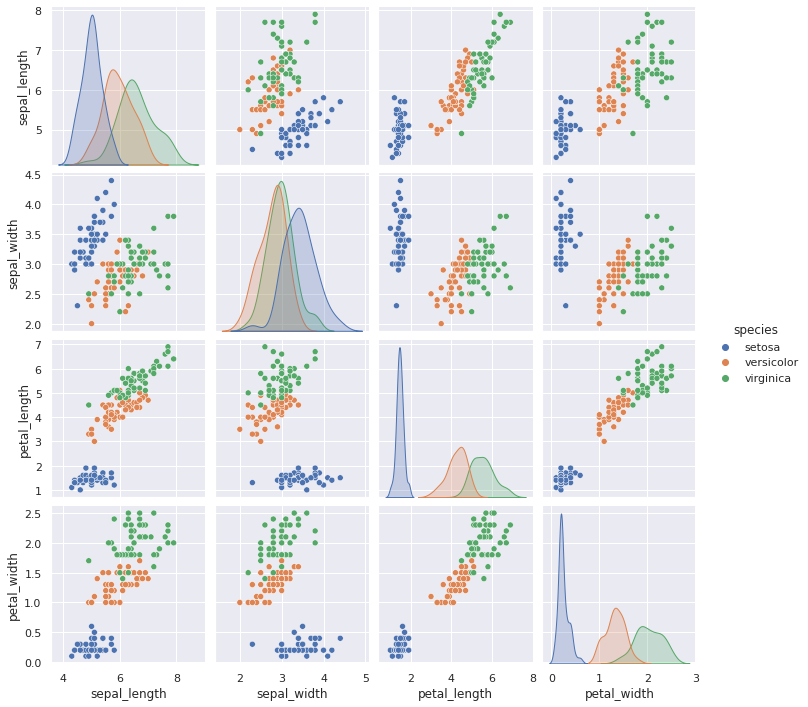

In [ ]:
sns.pairplot(iris,hue="species")
plt.show()

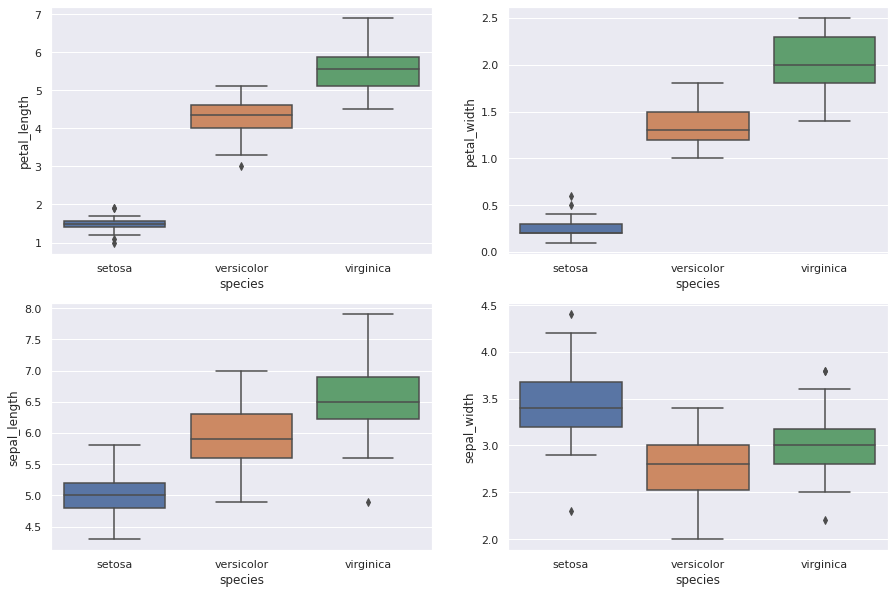

In [ ]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.boxplot(x='species',y='petal_length',data=iris)
plt.subplot(2,2,2)
sns.boxplot(x='species',y='petal_width',data=iris)
plt.subplot(2,2,3)
sns.boxplot(x='species',y='sepal_length',data=iris)
plt.subplot(2,2,4)
sns.boxplot(x='species',y='sepal_width',data=iris)
plt.show()

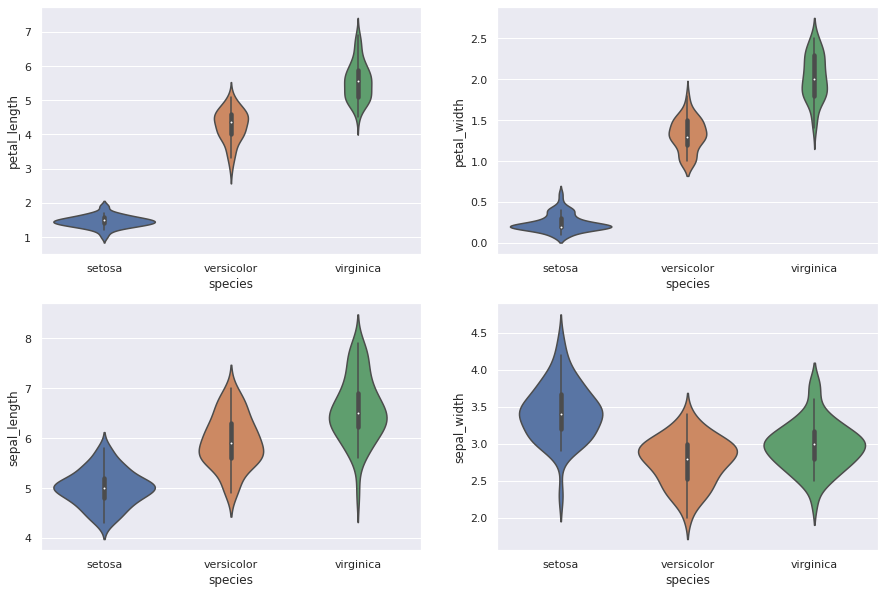

In [ ]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.violinplot(x='species',y='petal_length', data=iris)
plt.subplot(2,2,2)
sns.violinplot(x='species',y='petal_width',data=iris)
plt.subplot(2,2,3)
sns.violinplot(x='species',y='sepal_length',data=iris)
plt.subplot(2,2,4)
sns.violinplot(x='species',y='sepal_width',data=iris)
plt.show()

# Naive Bayes Classification

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

iris = load_iris()
X = iris.data.copy()
y = np.array([iris.target_names[yi] for yi in iris.target])
n_quantiles = 3
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [ ]:
# Simple quantization, maps each value to which quantile it belongs
def quantize(x, n_intervals=3):
    p = np.percentile(x, np.linspace(0, 100, num=(n_intervals+1)))
    return np.array([max(sum(xi > p), 1) for xi in x])

# Discretize features using simple quantile encoding, since we are
# implementing a multinomial version of the naive Bayes
for feature in range(X.shape[1]):
    X[:, feature] = quantize(X[:, feature], n_quantiles)
X = X.astype(int)

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print("Num. train instances:", len(X_train))
print("Num. test instances:", len(X_test))
print("Num. features:", X.shape[1])

Num. train instances: 120
Num. test instances: 30
Num. features: 4


In [ ]:
# Num. insances, num. features and num. classes
classes = np.unique(y)
n, d, C = X_train.shape[0], X_train.shape[1], len(classes)

# Laplace smoothing factor
alpha = 1

Train

In [ ]:
# We store the class probabilites in this dictionary
class_probs = {}

for c in classes:
    class_probs[c] = (np.array(y_train == c).sum() + alpha) / (n + C*alpha)

In [ ]:
# First, we get the list of possible values for each feature:
possible_values = [set(X_train[:, feature]) for feature in range(d)]

# We will store these probabilities in this dictionary
# The key of the dictionary is a pair of (feature, class) such that:
#   feature_probs[j, c]  
# gives a dictionary which maps each possible value of the j-th feature to 
# its probability, given each class, as we saw in the formula above, i.e.
# P(X_{i,j} = x | y_i = c) can be obtained from: feature_probs[j, c][k]
feature_probs = {(j, c): {v: 0 for v in possible_values[j]} 
                 for c in classes for j in range(d)}

# Now, we compute the above probabilites, for each feature, given each class
for j in range(d):
    for c in classes:
        # This gives us the j-th feature of instances in class c
        in_class_c = X_train[y_train == c, j]
        for x in possible_values[j]:
            numerator = sum(in_class_c == x) + alpha
            denominator = len(in_class_c) + len(possible_values[j])*alpha
            feature_probs[j, c][x] = numerator / denominator

Test

In [ ]:
test_size = len(X_test)
y_pred = []

for i in range(test_size):
    posterior_prob = {c: 0 for c in classes}
    y_max = classes[0]
    
    for c in classes:
        # Compute the posterior prob. for class c
        posterior_prob[c] = class_probs[c]
        for j in range(d):
            x = X_test[i, j]
            posterior_prob[c] *= feature_probs[j, c][x]
            
        # Update which class has the max posterior
        if posterior_prob[c] >= posterior_prob[y_max]:
            y_max = c
    y_pred.append(y_max)
print(classification_report(y_test, y_pred))

# no k-fold here, but will have a similar accuracy level after repeating k times

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.78      0.88         9

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



# Another implementation

In [5]:
# Naive Bayes On The Iris Dataset
from csv import reader
from random import seed
from random import randrange
from math import sqrt
from math import exp
from math import pi

# Load a CSV file
def load_csv(filename):
	dataset = list()
	with open(filename, 'r') as file:
		csv_reader = reader(file)
		for row in csv_reader:
			if not row:
				continue
			dataset.append(row)
	return dataset

# Convert string column to float
def str_column_to_float(dataset, column):
	for row in dataset:
		row[column] = float(row[column].strip())

# Convert string column to integer
def str_column_to_int(dataset, column):
	class_values = [row[column] for row in dataset]
	unique = set(class_values)
	lookup = dict()
	for i, value in enumerate(unique):
		lookup[value] = i
	for row in dataset:
		row[column] = lookup[row[column]]
	return lookup

# Split a dataset into k folds
def cross_validation_split(dataset, n_folds):
	dataset_split = list()
	dataset_copy = list(dataset)
	fold_size = int(len(dataset) / n_folds)
	for _ in range(n_folds):
		fold = list()
		while len(fold) < fold_size:
			index = randrange(len(dataset_copy))
			fold.append(dataset_copy.pop(index))
		dataset_split.append(fold)
	return dataset_split

# Calculate accuracy percentage
def accuracy_metric(actual, predicted):
	correct = 0
	for i in range(len(actual)):
		if actual[i] == predicted[i]:
			correct += 1
	return correct / float(len(actual)) * 100.0

# Calculate the mean of a list of numbers
def mean(numbers):
	return sum(numbers)/float(len(numbers))



################# Naive Bayes Classifiction, Core Code below ###############

# Split the dataset by class values, returns a dictionary
def separate_by_class(dataset):
	separated = dict()
	for i in range(len(dataset)):
		vector = dataset[i]
		class_value = vector[-1]
		if (class_value not in separated):
			separated[class_value] = list()
		separated[class_value].append(vector)
	return separated

# Calculate the standard deviation of a list of numbers
def stdev(numbers):
	avg = mean(numbers)
	variance = sum([(x-avg)**2 for x in numbers]) / float(len(numbers)-1)
	return sqrt(variance)


# Calculate the Gaussian probability distribution function for x
def calculate_probability(x, mean, stdev):
	exponent = exp(-((x-mean)**2 / (2 * stdev**2 )))
	return (1 / (sqrt(2 * pi) * stdev)) * exponent

# Calculate the probabilities of predicting each class for a given row
def calculate_class_probabilities(summaries, row):
	total_rows = sum([summaries[label][0][2] for label in summaries])
	probabilities = dict()
	for class_value, class_summaries in summaries.items():
		probabilities[class_value] = summaries[class_value][0][2]/float(total_rows)
		for i in range(len(class_summaries)):
			mean, stdev, _ = class_summaries[i]
			# Feature-wise product
			probabilities[class_value] *= calculate_probability(row[i], mean, stdev)
	return probabilities

# Predict the class for a given row
def predict(summaries, row):
	probabilities = calculate_class_probabilities(summaries, row)
	best_label, best_prob = None, -1
	for class_value, probability in probabilities.items():
		if best_label is None or probability > best_prob:
			best_prob = probability
			best_label = class_value
	return best_label

# Calculate the mean, stdev and count for each column in a dataset
def summarize_dataset(dataset):
	summaries = [(mean(column), stdev(column), len(column)) for column in zip(*dataset)]
	del(summaries[-1])
	return summaries

# Split dataset by class then calculate statistics for each row
def summarize_by_class(dataset):
	separated = separate_by_class(dataset)
	summaries = dict()
	for class_value, rows in separated.items():
		summaries[class_value] = summarize_dataset(rows)
	return summaries

# Naive Bayes Algorithm
def naive_bayes(train, test):
	summarize = summarize_by_class(train)
	predictions = list()
	for row in test:
		output = predict(summarize, row)
		predictions.append(output)
	return(predictions)

# Evaluate an algorithm using a cross validation split
def evaluate_algorithm(dataset, algorithm, n_folds, *args):
	folds = cross_validation_split(dataset, n_folds)
	scores = list()
	for fold in folds:
		train_set = list(folds)
		train_set.remove(fold)
		train_set = sum(train_set, [])
		test_set = list()
		for row in fold:
			row_copy = list(row)
			test_set.append(row_copy)
			row_copy[-1] = None
		predicted = algorithm(train_set, test_set, *args)
		actual = [row[-1] for row in fold]
		accuracy = accuracy_metric(actual, predicted)
		scores.append(accuracy)

	return scores


# Test Naive Bayes on Iris Dataset
seed(1)
filename = 'iris.csv'
dataset = load_csv(filename)
for i in range(len(dataset[0])-1):
	str_column_to_float(dataset, i)
# convert class column to integers
str_column_to_int(dataset, len(dataset[0])-1)

# evaluate algorithm
n_folds = 5
scores = evaluate_algorithm(dataset, naive_bayes, n_folds)
print(cross_validation_split(dataset, n_folds))
print('Scores: %s' % scores)
print('Mean Accuracy: %.3f%%' % (sum(scores)/float(len(scores))))

[[[5.1, 3.3, 1.7, 0.5, 2], [5.8, 2.7, 5.1, 1.9, 0], [5.6, 3.0, 4.5, 1.5, 1], [4.4, 2.9, 1.4, 0.2, 2], [5.1, 3.8, 1.5, 0.3, 2], [4.8, 3.4, 1.9, 0.2, 2], [5.0, 3.6, 1.4, 0.2, 2], [5.6, 2.8, 4.9, 2.0, 0], [4.6, 3.1, 1.5, 0.2, 2], [6.0, 2.9, 4.5, 1.5, 1], [5.9, 3.2, 4.8, 1.8, 1], [6.8, 2.8, 4.8, 1.4, 1], [4.9, 3.1, 1.5, 0.1, 2], [6.5, 2.8, 4.6, 1.5, 1], [6.3, 3.3, 6.0, 2.5, 0], [6.7, 3.1, 4.7, 1.5, 1], [5.1, 3.7, 1.5, 0.4, 2], [7.0, 3.2, 4.7, 1.4, 1], [5.3, 3.7, 1.5, 0.2, 2], [5.5, 2.4, 3.8, 1.1, 1], [5.5, 2.3, 4.0, 1.3, 1], [6.3, 2.3, 4.4, 1.3, 1], [5.6, 2.7, 4.2, 1.3, 1], [6.3, 2.5, 4.9, 1.5, 1], [6.4, 2.7, 5.3, 1.9, 0], [6.4, 3.2, 4.5, 1.5, 1], [5.8, 2.7, 3.9, 1.2, 1], [6.7, 3.0, 5.0, 1.7, 1], [5.1, 3.5, 1.4, 0.3, 2], [5.4, 3.9, 1.7, 0.4, 2]], [[6.9, 3.1, 4.9, 1.5, 1], [6.7, 3.1, 4.4, 1.4, 1], [5.2, 2.7, 3.9, 1.4, 1], [6.4, 2.9, 4.3, 1.3, 1], [6.1, 2.6, 5.6, 1.4, 0], [5.5, 4.2, 1.4, 0.2, 2], [5.1, 3.8, 1.9, 0.4, 2], [5.7, 3.8, 1.7, 0.3, 2], [4.8, 3.0, 1.4, 0.3, 2], [7.4, 2.8, 6.1, 1.9, 